## 바이오 빅데이터 분석 (3)
### 분류 분석 실습: CancerSEEK protein marker 기반 암 진단 및 암종 분류

이 노트북은 CancerSEEK 데이터의 혈액 단백질 marker를 사용해 기계학습 분류 문제를 실습하는 자료입니다.

실습의 주요 흐름은 다음과 같습니다.

1. 데이터 로드
2. 데이터 탐색
3. 전처리
4. 암 진단 이진 분류: `Normal` vs `Cancer`
5. Cross-validation으로 일반화 성능 추정
6. Threshold 바꿔보기
7. ROC & AUC
8. GridSearchCV로 Logistic Regression 하이퍼파라미터 최적화
9. 모델 비교
10. 암종 다중 분류
11. 다중 분류 cross-validation 및 one-vs-rest ROC-AUC
12. Feature importance: 어떤 protein marker가 중요한가?
13. 차원 축소 시각화
14. 병기별 성능 확인
15. 과제

분류 문제에서는 단순히 정확도만 보는 것이 위험할 수 있습니다. 특히 암 진단처럼 양성/음성의 의미가 중요한 문제에서는 sensitivity, specificity, ROC-AUC, PR-AUC, confusion matrix를 함께 확인해야 합니다.


### 0. 실행 환경

로컬 폴더의 `data_CancerSEEK/*.csv` 파일을 우선 사용합니다. 데이터 파일이 없는 환경에서는 기존 `MLBI_Training_pkg` 안의 CancerSEEK 폴더를 자동으로 찾아봅니다.

이 실습에서는 `CancerSEEK Logistic Regression Score`와 `CancerSEEK Test Result`를 feature로 사용하지 않습니다. 이 값들은 원 논문/데이터에서 이미 만들어진 진단 점수와 결과이므로, 모델 입력에 넣으면 정답 정보를 간접적으로 사용하는 data leakage가 됩니다.


In [ ]:
# Colab에서 로컬 CSV가 없을 때만 실행하세요.
# !pip install mlbi-lab
# !pip install xgboost
# !pip install umap-learn

In [ ]:
import os
from pathlib import Path
import warnings

# 일부 서버/노트북 환경에서 matplotlib cache 경고를 줄이기 위한 설정입니다.
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics as met
from sklearn import model_selection as mod_sel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

warnings.filterwarnings('ignore')
RANDOM_STATE = 5
sns.set_theme(style='whitegrid', context='notebook')


### 1. 데이터 로드

CancerSEEK 데이터는 두 개의 표로 구성됩니다.

- `CancerSEEK_protein.csv`: 샘플 x 단백질 marker 행렬
- `CancerSEEK_clinical_info.csv`: 샘플별 암종, 병기, 나이, 성별, 기존 CancerSEEK 판정 결과

이 실습의 입력 feature는 protein marker만 사용합니다.


In [ ]:
def load_cancerseek(base_dir='data_CancerSEEK'):
    """Load CancerSEEK data from local CSV files or known workshop folders."""
    candidate_dirs = [
        Path(base_dir),
        Path('Work_BioBigdata_KOTHEA') / base_dir,
        Path('../Work_BioBigdata_KOTHEA') / base_dir,
        Path('MLBI_Training_pkg/MLBI_Training_pkg_KOTHEA/data_CancerSEEK'),
        Path('../MLBI_Training_pkg/MLBI_Training_pkg_KOTHEA/data_CancerSEEK'),
        Path('MLBI_Training_pkg/AID_bio_bigdata_workshop_1/data'),
        Path('../MLBI_Training_pkg/AID_bio_bigdata_workshop_1/data'),
    ]

    for base in candidate_dirs:
        protein_file = base / 'CancerSEEK_protein.csv'
        clinical_file = base / 'CancerSEEK_clinical_info.csv'
        if protein_file.exists() and clinical_file.exists():
            protein = pd.read_csv(protein_file, index_col=0)
            clinical = pd.read_csv(clinical_file, index_col=0)
            print('Loaded data from:', base)
            return {'protein_expression': protein, 'clinical_info': clinical}

    raise FileNotFoundError('CancerSEEK CSV files were not found. Check data_CancerSEEK/.')


data = load_cancerseek()
df_protein = data['protein_expression']
df_clinical = data['clinical_info']

print('protein matrix:', df_protein.shape)
print('clinical info :', df_clinical.shape)
print('index aligned :', df_protein.index.equals(df_clinical.index))


In [ ]:
display(df_protein.head())
display(df_clinical.head())

In [ ]:
## Add mutant feature (Omega score) to df_protein
df_protein["Omega"] = df_clinical["Omega score"].copy(deep = True)
b = df_protein["Omega"].isnull()
df_protein["Omega"][b] = 0

#### Data source

Detection and localization of surgically resectable cancers with a multi-analyte blood test, _Science_, 2018
https://www.science.org/doi/10.1126/science.aar3247 

### 2. 데이터 탐색

먼저 암종별 샘플 수, 기존 CancerSEEK 판정 결과, 병기 분포를 확인합니다. 분류 문제에서는 class imbalance가 성능 평가에 큰 영향을 주므로, class별 샘플 수를 꼭 확인해야 합니다.


In [ ]:
print('Missing protein values:', int(df_protein.isna().sum().sum()))
print('Duplicated sample IDs:', int(df_protein.index.duplicated().sum()))

display(df_clinical['Tumor type'].value_counts().rename('n_samples').to_frame())
display(pd.crosstab(df_clinical['Tumor type'], df_clinical['CancerSEEK Test Result']))
display(pd.crosstab(df_clinical['Tumor type'], df_clinical['AJCC Stage']))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(
    data=df_clinical,
    y='Tumor type',
    order=df_clinical['Tumor type'].value_counts().index,
    color='steelblue',
    ax=axes[0],
)
axes[0].set_title('Number of samples by tumor type')
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('')

sns.countplot(
    data=df_clinical,
    x='CancerSEEK Test Result',
    hue='Tumor type',
    ax=axes[1],
)
axes[1].set_title('Original CancerSEEK test result')
axes[1].set_xlabel('')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Tumor type')

plt.tight_layout()


### 3. 전처리

단백질 농도값은 오른쪽으로 긴 분포를 갖는 경우가 많으므로 `log10(x + 1)` 변환을 적용합니다. 이후 `StandardScaler`는 model pipeline 안에 넣어 train/test 분할 이후에 학습되도록 합니다.

여기서 만드는 label은 두 가지입니다.

- `y_binary`: `Normal`이면 0, 암이면 1
- `y_type`: 암종 이름 자체를 예측하는 다중분류 label


In [ ]:
X_raw = df_protein.copy()
X_log = np.log10(X_raw + 1)

clinical = df_clinical.reindex(X_log.index).copy()
y_binary = (clinical['Tumor type'] != 'Normal').astype(int)
y_type = clinical['Tumor type'].copy()

print('X:', X_log.shape)
print('Binary label counts:')
display(y_binary.value_counts().rename(index={0: 'Normal', 1: 'Cancer'}).to_frame('n_samples'))
print('Multiclass label counts:')
display(y_type.value_counts().to_frame('n_samples'))


In [ ]:
plt.figure(figsize=(12, 4))
example_markers = ['CA-125', 'CEA', 'CA19-9', 'OPN', 'TIMP-1']
example_markers = [marker for marker in example_markers if marker in X_log.columns]

plot_df = X_log[example_markers].copy()
plot_df['Tumor type'] = y_type.values
plot_long = plot_df.melt(id_vars='Tumor type', var_name='protein', value_name='log10(value + 1)')

sns.boxplot(data=plot_long, x='protein', y='log10(value + 1)', hue='Tumor type')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Tumor type')
plt.title('Example protein marker distributions')
plt.tight_layout()


### 4. 암 진단 이진 분류: Normal vs Cancer

첫 번째 문제는 가장 기본적인 암 진단 문제입니다. 혈액 단백질 marker 39개를 사용해 샘플이 `Normal`인지 `Cancer`인지 예측합니다.

<div style="display:flex; gap:24px; align-items:flex-start;">
  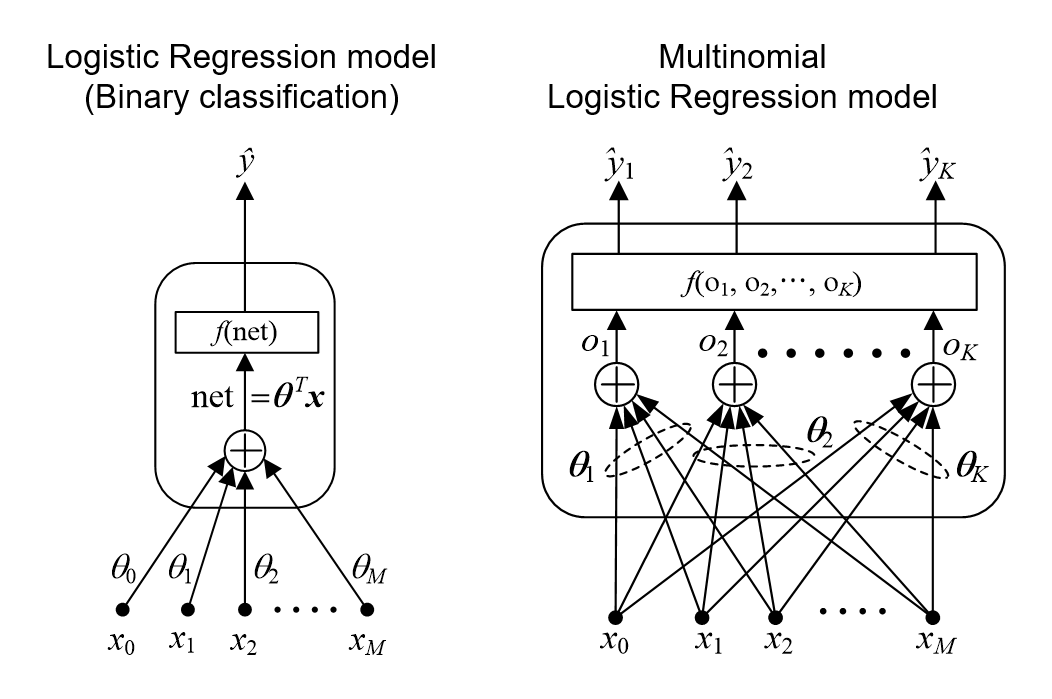  
</div>


## Model:

### (Binary) Logistic regression with $l_1$ and $l_2$ penalty
model description: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
<br>
model usage: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

#### Model (logistic sigmoid function): $$ \hat{p}_1 = s\left({\bf{x}}^T_i {\boldsymbol{\theta}} + c \right) = \frac{1}{1 + e^{ - \left( {\bf{x}}^T_i {\boldsymbol{\theta}} + c \right)}} = Pr\{ {\bf{x}}_i {\text{ belongs to class 1}} \}$$
#### Cost to minimize (negative log-likelihood): $$ \min_{{\boldsymbol{\theta}},c} C \sum^{n}_{i=1} \log \left( 1 + \exp ^{ (1-2y_i) \left( {\bf x}^T_i {\boldsymbol{\theta}} + c \right)} \right) + \frac{1-\rho}{2} {\boldsymbol{\theta}}^T{\boldsymbol{\theta}} + \rho \| {\boldsymbol{\theta}} \|_1 $$
where
1. $C$ controls the relative weight between RSS (1st term) and penaties (2nd and 3rd terms).
2. $\rho$ controls the relative weight between $l_1$ and $l_2$ penalty. $\rho = 1$ corresponds to LASSO while $\rho=0$ to Ridge.
3. $C \rightarrow \infty $ means no penalty.

평가할 지표는 다음과 같습니다.

- **Accuracy**: 전체 중 맞춘 비율
- **Sensitivity / Recall / TPR**: 실제 암 샘플 중 암으로 맞춘 비율
- **Specificity / TNR**: 실제 정상 샘플 중 정상으로 맞춘 비율
- **Precision / PPV**: 암이라고 예측한 샘플 중 실제 암 비율
- **ROC-AUC**: threshold 전반에서 양성과 음성을 구분하는 능력
- **PR-AUC**: 양성 class 중심의 precision-recall 성능

In [ ]:
def binary_classification_scores(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = met.confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    scores = {
        'accuracy': met.accuracy_score(y_true, y_pred),
        'balanced_accuracy': met.balanced_accuracy_score(y_true, y_pred),
        'sensitivity_recall': tp / (tp + fn) if (tp + fn) else np.nan,
        'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'precision_ppv': met.precision_score(y_true, y_pred, zero_division=0),
        'f1': met.f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        scores['roc_auc'] = met.roc_auc_score(y_true, y_score)
        scores['average_precision'] = met.average_precision_score(y_true, y_score)
    return scores


def plot_binary_confusion_matrix(y_true, y_pred, title='Confusion matrix'):
    cm = met.confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = met.ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Cancer'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.grid(False)
    plt.tight_layout()


In [ ]:
X_train, X_test, y_train, y_test = mod_sel.train_test_split(
    X_log,
    y_binary,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)

binary_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

binary_lr.fit(X_train, y_train)
y_test_pred = binary_lr.predict(X_test)
y_test_score = binary_lr.decision_function(X_test)
y_test_prob = binary_lr.predict_proba(X_test)[:, 1]

pd.Series(binary_classification_scores(y_test, y_test_pred, y_test_score), name='Logistic regression test')


In [ ]:
y_train_pred = binary_lr.predict(X_train)
y_train_score = binary_lr.decision_function(X_train)
y_train_prob = binary_lr.predict_proba(X_train)[:, 1]

train_test_result_df = pd.DataFrame([
    binary_classification_scores(y_train, y_train_pred, y_train_score),
    binary_classification_scores(y_test, y_test_pred, y_test_score),
], index=['train', 'test'])

train_test_result_df.loc['gap(train-test)'] = (
    train_test_result_df.loc['train'] - train_test_result_df.loc['test']
)

train_test_result_df


### 5. Cross-validation으로 일반화 성능 추정

Train/test split은 한 번의 분할에 결과가 영향을 받을 수 있습니다. Cross-validation을 사용하면 여러 번의 validation 결과를 합쳐 더 안정적인 일반화 성능을 볼 수 있습니다.


In [ ]:
NCV = 5
cv = mod_sel.StratifiedKFold(n_splits=NCV, shuffle=True, random_state=RANDOM_STATE)

binary_cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

y_pred_cv = mod_sel.cross_val_predict(binary_cv_model, X_log, y_binary, cv=cv, n_jobs=-1, method='predict')
y_prob_cv = mod_sel.cross_val_predict(binary_cv_model, X_log, y_binary, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]
y_score_cv = mod_sel.cross_val_predict(binary_cv_model, X_log, y_binary, cv=cv, n_jobs=-1, method='decision_function')

pd.Series(binary_classification_scores(y_binary, y_pred_cv, y_score_cv), name=f'{NCV}-fold CV')


In [ ]:
plot_binary_confusion_matrix(y_binary, y_pred_cv, title=f'Normal vs Cancer: {NCV}-fold CV')


#### 기존 CancerSEEK 판정과 비교

데이터에는 이미 `CancerSEEK Logistic Regression Score`와 `CancerSEEK Test Result`가 포함되어 있습니다. 이것은 우리가 만드는 모델의 입력 feature가 아니라, 비교용 baseline으로만 사용합니다.


In [ ]:
official_result = clinical.loc[y_binary.index, 'CancerSEEK Test Result'].map({'Negative': 0, 'Positive': 1}).astype(int)
official_score = clinical.loc[y_binary.index, 'CancerSEEK Logistic Regression Score'].astype(float)

comparison = pd.DataFrame([
    binary_classification_scores(y_binary, y_pred_cv, y_score_cv),
    binary_classification_scores(y_binary, official_result, official_score),
], index=['Our logistic regression (5-fold CV)', 'Original CancerSEEK result'])
comparison


In [ ]:
plot_binary_confusion_matrix(y_binary, official_result, title='Normal vs Cancer: Original CancerSEEK result')


#### 예측 score 분포 확인

`y_score_cv`는 cross-validation에서 계산한 decision score입니다. Logistic regression에서는 이 값이 logistic sigmoid 함수에 들어가기 전의 선형 점수이며, `0`보다 크면 Cancer class 쪽으로 예측됩니다. Normal과 Cancer의 score 분포가 잘 분리될수록 ROC-AUC가 높아집니다.

Threshold 실습에는 해석이 쉬운 probability(`y_prob_cv`)를 사용하고, ROC-AUC와 score 분포 확인에는 decision score(`y_score_cv`)를 사용합니다.


In [ ]:
score_df = pd.DataFrame({
    'Decision score': y_score_cv,
    'True label': np.where(y_binary == 1, 'Cancer', 'Normal'),
})

plt.figure(figsize=(7, 4.5))
sns.histplot(
    data=score_df,
    x='Decision score',
    hue='True label',
    bins=30,
    stat='density',
    common_norm=False,
    alpha=0.35,
    element='step',
)
sns.kdeplot(
    data=score_df,
    x='Decision score',
    hue='True label',
    common_norm=False,
    linewidth=2,
    legend=False,
)
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='decision threshold = 0')
plt.xlabel('Decision score before logistic sigmoid')
plt.ylabel('Density')
plt.title('Cross-validated decision score distribution')
plt.legend(loc='upper center')
plt.tight_layout()


#### 실습 A

아래 `practice_threshold` 값을 바꿔가며 confusion matrix와 sensitivity/specificity가 어떻게 달라지는지 확인하세요.


In [ ]:
practice_threshold = 1

y_pred_practice = (y_score_cv >= practice_threshold).astype(int)
display(pd.Series(binary_classification_scores(y_binary, y_pred_practice, y_score_cv), name=f'probability threshold={practice_threshold:.2f}'))
plot_binary_confusion_matrix(y_binary, y_pred_practice, title=f'Probability threshold = {practice_threshold:.2f}')


### 6. Threshold 바꿔보기

분류 모델은 decision score를 logistic sigmoid 함수에 통과시켜 probability를 만들고, 보통 `0.5` 같은 probability threshold를 기준으로 label을 정합니다. 암 진단 문제에서는 threshold를 낮추면 sensitivity가 올라가고, 반대로 specificity가 낮아질 수 있습니다.

아래 셀에서 threshold를 바꾸며 지표가 어떻게 달라지는지 확인해보세요.


In [ ]:
threshold_grid = np.arange(-4, 5, 1)
threshold_rows = []

for threshold in threshold_grid:
    y_pred_threshold = (y_score_cv >= threshold).astype(int)
    row = binary_classification_scores(y_binary, y_pred_threshold, y_score_cv)
    row['threshold'] = threshold
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows).set_index('threshold')
threshold_df[['sensitivity_recall', 'precision_ppv', 'f1', 'balanced_accuracy']].head()


In [ ]:
plt.figure(figsize=(7, 4))
for metric_name in ['sensitivity_recall', 'precision_ppv', 'f1']:
    plt.plot(threshold_df.index, threshold_df[metric_name], marker='o', label=metric_name)

plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Threshold-dependent binary classification metrics')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()


- Accuracy $= \frac{TP+TN}{TP+TN+FP+FN}$

- Sensitivity (Recall) $= \frac{TP}{TP+FN} = TPR$

- Precision $= \frac{TP}{TP+FP}$

- Specificity $= \frac{TN}{TN+FP}$

- FPR $= \frac{FP}{TN+FP}$

### 7. ROC & AUC

ROC curve는 분류 threshold를 0에서 1까지 바꾸면서 **false positive rate (FPR)**와 **true positive rate (TPR, sensitivity)**가 어떻게 변하는지 보여주는 그래프입니다. 암 진단 모델에서는 threshold를 낮추면 더 많은 샘플을 Cancer로 판정하므로 sensitivity는 올라갈 수 있지만, 정상 샘플을 암으로 잘못 판정하는 false positive도 함께 늘어날 수 있습니다.

AUC는 ROC curve 아래 면적으로, 모델이 무작위로 고른 암 샘플에 정상 샘플보다 더 높은 cancer score를 줄 확률로 해석할 수 있습니다. AUC가 0.5에 가까우면 무작위 분류와 비슷하고, 1.0에 가까울수록 두 class를 잘 구분하는 모델입니다. 다만 실제 진단에서는 AUC가 높더라도 어떤 threshold를 선택하느냐에 따라 sensitivity와 specificity가 달라지므로, confusion matrix와 함께 해석해야 합니다.

Precision-Recall curve는 positive class, 여기서는 Cancer class에 더 초점을 둔 평가입니다. 양성 class가 드물거나 false positive의 영향이 중요한 문제에서는 ROC curve와 함께 PR curve를 확인하는 것이 좋습니다.



<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="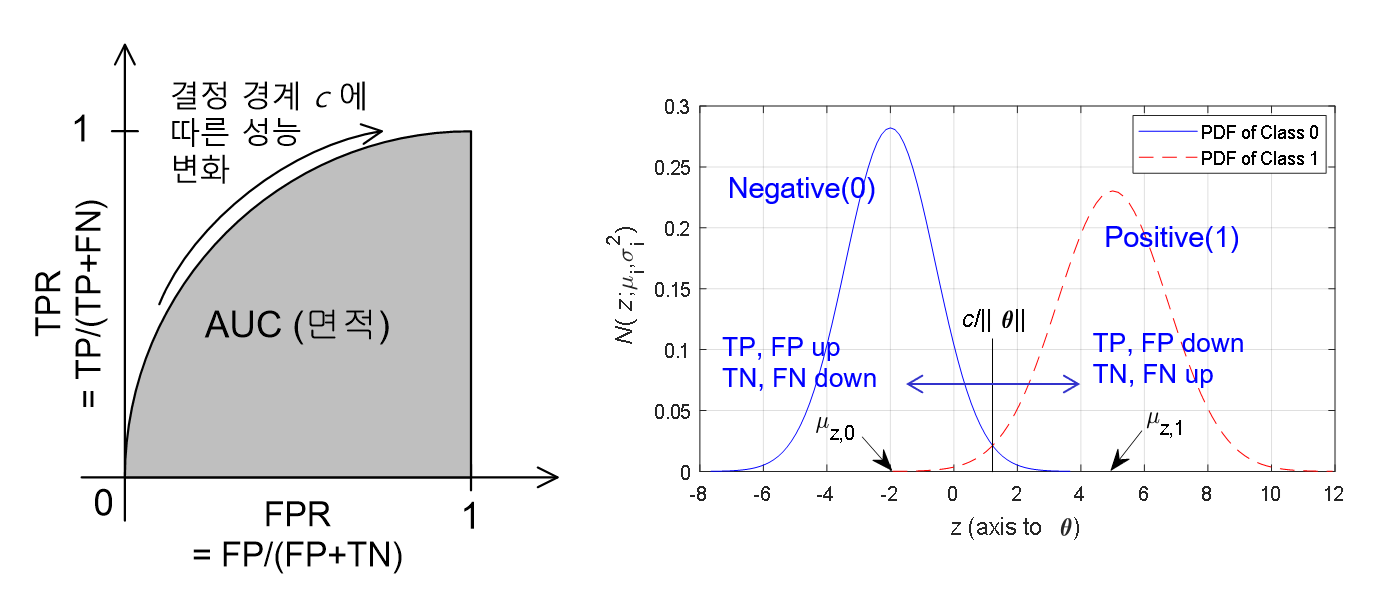
" width="700"/>  
</div>


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

met.RocCurveDisplay.from_predictions(y_binary, y_score_cv, ax=axes[0], name='Logistic regression')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC curve')

met.PrecisionRecallDisplay.from_predictions(y_binary, y_score_cv, ax=axes[1], name='Logistic regression')
axes[1].set_title('Precision-Recall curve')

plt.tight_layout()


### 8. GridSearchCV로 Logistic Regression 하이퍼파라미터 최적화

Logistic regression의 `C`는 regularization strength의 역수입니다. 작은 `C`는 더 강한 규제를 의미하고, 큰 `C`는 규제가 약해집니다.

여기서는 `elasticnet` penalty를 고정한 뒤 ROC-AUC를 기준으로 `C`와 `l1_ratio`를 함께 탐색합니다. `l1_ratio=0`은 Ridge에 가깝고, `l1_ratio=1`은 LASSO에 가까우며, 중간값은 두 규제를 섞어 사용합니다.


In [ ]:
grid_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

param_grid = {
    'model__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    'model__l1_ratio': [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
}

gs = mod_sel.GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs.fit(X_log, y_binary)
print('Best CV ROC-AUC:', round(gs.best_score_, 3))
print('Best params:', gs.best_params_)


In [ ]:
best_binary_model = gs.best_estimator_
y_pred_best_cv = mod_sel.cross_val_predict(best_binary_model, X_log, y_binary, cv=cv, n_jobs=-1, method='predict')
y_score_best_cv = mod_sel.cross_val_predict(best_binary_model, X_log, y_binary, cv=cv, n_jobs=-1, method='decision_function')
y_prob_best_cv = mod_sel.cross_val_predict(best_binary_model, X_log, y_binary, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]

pd.Series(binary_classification_scores(y_binary, y_pred_best_cv, y_score_best_cv), name='Best logistic regression CV')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

met.RocCurveDisplay.from_predictions(y_binary, y_score_best_cv, ax=axes[0], name='Logistic regression')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC curve')

met.PrecisionRecallDisplay.from_predictions(y_binary, y_score_best_cv, ax=axes[1], name='Logistic regression')
axes[1].set_title('Precision-Recall curve')

plt.tight_layout()


### 9. RandomForest 및 XGBoost 모델과 성능 비교

같은 binary classification 문제에 대해 Logistic Regression, RandomForest, XGBoost를 비교합니다. RandomForest와 XGBoost는 비선형 관계를 잡을 수 있지만, 작은 feature 수와 class imbalance에서는 해석과 일반화 성능을 함께 봐야 합니다.

XGBoost가 설치되어 있지 않은 환경에서는 해당 모델을 자동으로 건너뜁니다.


In [ ]:
binary_models = {
    'LogisticRegression': best_binary_model,
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

try:
    from xgboost import XGBClassifier

    n_negative = int((y_binary == 0).sum())
    n_positive = int((y_binary == 1).sum())
    scale_pos_weight = n_negative / n_positive

    binary_models['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
except ImportError:
    print('xgboost is not installed. XGBoost will be skipped.')

model_rows = []
for model_name, model in binary_models.items():
    print('Evaluating:', model_name)
    y_pred = mod_sel.cross_val_predict(model, X_log, y_binary, cv=cv, n_jobs=-1, method='predict')

    if hasattr(model, 'decision_function'):
        y_model_score = mod_sel.cross_val_predict(model, X_log, y_binary, cv=cv, n_jobs=-1, method='decision_function')
    else:
        y_model_score = mod_sel.cross_val_predict(model, X_log, y_binary, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]

    row = binary_classification_scores(y_binary, y_pred, y_model_score)
    row['model'] = model_name
    model_rows.append(row)

binary_model_result_df = pd.DataFrame(model_rows).set_index('model').sort_values('roc_auc', ascending=False)
binary_model_result_df


In [ ]:
plt.figure(figsize=(8, 4))
plot_df = binary_model_result_df[['roc_auc', 'average_precision', 'sensitivity_recall', 'specificity']].reset_index().melt(
    id_vars='model', var_name='metric', value_name='score'
)
sns.barplot(data=plot_df, x='metric', y='score', hue='model')
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.title('Binary classification model comparison')
plt.legend(bbox_to_anchor = (1,1))
plt.tight_layout()


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1,
)

rf_prob_cv = mod_sel.cross_val_predict(
    rf_model,
    X_log,
    y_binary,
    cv=cv,
    n_jobs=-1,
    method='predict_proba'
)[:, 1]

plt.figure(figsize=(5, 5))
ax = plt.gca()

met.RocCurveDisplay.from_predictions( y_binary, y_score_best_cv, name='Logistic regression', ax=ax )
met.RocCurveDisplay.from_predictions( y_binary, rf_prob_cv, name='RandomForest', ax=ax )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC curve: Logistic regression vs RandomForest')
plt.tight_layout()

### 10. 암종 다중 분류

이제 정상 샘플을 제외하고 암 샘플만 사용해 암종을 예측합니다. 샘플 수가 암종별로 다르기 때문에 `class_weight='balanced'`를 사용하고, macro 평균 지표를 함께 확인합니다.

- **macro F1**: 각 class의 F1을 동일한 비중으로 평균
- **weighted F1**: 샘플 수를 반영해 평균
- **balanced accuracy**: class imbalance를 고려한 accuracy


<div style="display:flex; gap:24px; align-items:flex-start;">
  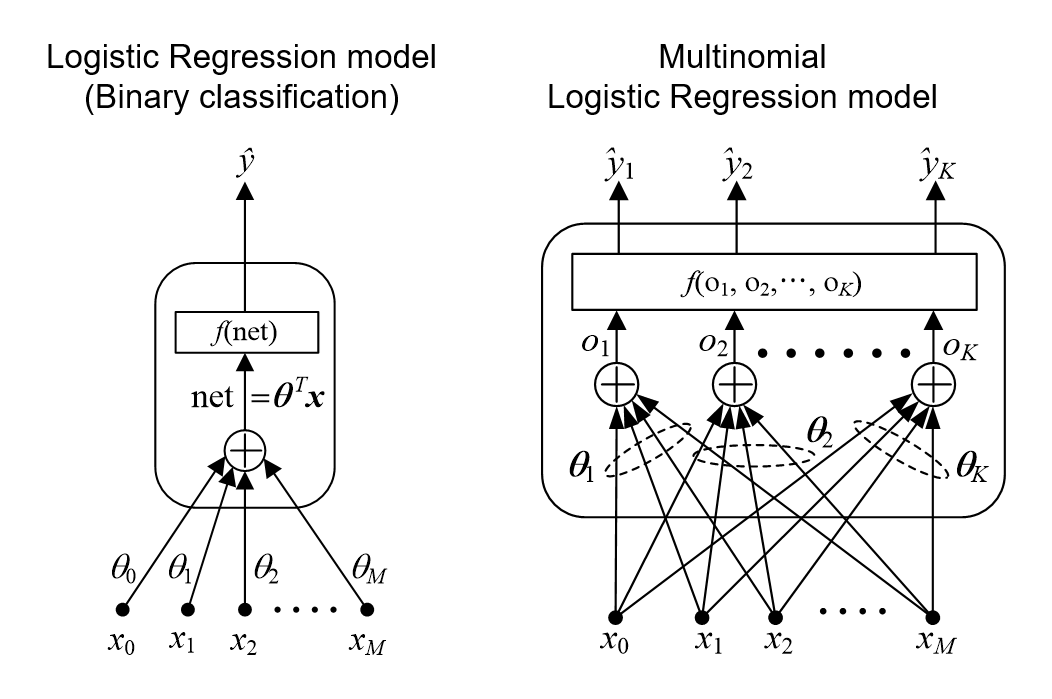  
</div>


## Model:

### (Multinomial) Logistic regression with $l_1$ and $l_2$ penalty


#### Model (softmax function): $$ S_{j}\left( {{\Theta}}^T {\bf x}_i + {\bf{c}} \right) = \frac{e^{ - \left( {\bf x}^T_i {\boldsymbol{\theta}}_{j} + c_j \right)}}{\sum^{K}_{k=1} e^{ - \left( {\bf{x}}^T_i {\boldsymbol{\theta}}_{k} + c_k \right)}} = Pr\{ {\bf{x}}_i {\text{ belongs to class }} j \}$$
#### Cost to minimize (negative log-likelihood): $$ \min_{{{\bf \Theta}, {\bf{c}}}} - C \sum^{n}_{i=1} \log S_{y_i}\left( {\bf \Theta}^T {\bf x}_i + {\bf{c}} \right) + \frac{1-\rho}{2} \| {\bf \Theta} \|^2_F + \rho \| {\bf \Theta} \|_{21} $$
where $S_y(\cdot)$ is soft-max function, ${\bf \Theta}$ is $M \times K$ parameter matrix and $ {\bf{c}}$ is $K \times 1$ intercept vector.


In [ ]:
cancer_mask = clinical['Tumor type'].notna() 
X_cancer = X_log.loc[cancer_mask].copy()
y_cancer_type = clinical.loc[cancer_mask, 'Tumor type'].copy()

print('Cancer-only X:', X_cancer.shape)
display(y_cancer_type.value_counts().to_frame('n_samples'))


In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = mod_sel.train_test_split(
    X_cancer,
    y_cancer_type,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_cancer_type,
)

multi_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

multi_lr.fit(X_train_m, y_train_m)
y_test_m_pred = multi_lr.predict(X_test_m)
y_test_m_proba = multi_lr.predict_proba(X_test_m)

print(met.classification_report(y_test_m, y_test_m_pred, digits=3))
print('Balanced accuracy:', round(met.balanced_accuracy_score(y_test_m, y_test_m_pred), 3))
print('Macro F1:', round(met.f1_score(y_test_m, y_test_m_pred, average='macro'), 3))


In [ ]:
labels_m = multi_lr.named_steps['model'].classes_
cm_m = met.confusion_matrix(y_test_m, y_test_m_pred, labels=labels_m)
cm_m_norm = met.confusion_matrix(y_test_m, y_test_m_pred, labels=labels_m, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', xticklabels=labels_m, yticklabels=labels_m, ax=axes[0])
axes[0].set_title('Multiclass confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_m_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels_m, yticklabels=labels_m, ax=axes[1])
axes[1].set_title('Normalized by true class')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()


### 11. 다중 분류 cross-validation 및 one-vs-rest ROC-AUC

다중 분류 성능은 먼저 하나의 multiclass logistic regression으로 평가합니다. 이후 ROC curve와 Precision-Recall curve는 각 암종을 양성 class로 두고 나머지 암종을 음성 class로 두는 **one-vs-rest binary classifier**를 class별로 따로 학습하여 그립니다.

이렇게 하면 softmax multiclass probability를 억지로 one-vs-rest처럼 해석하는 것보다, 각 암종별 binary detection 문제의 성능을 더 직접적으로 볼 수 있습니다.


In [ ]:
cv_multi = mod_sel.StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

multi_cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)),
])

y_pred_multi_cv = mod_sel.cross_val_predict(multi_cv_model, X_cancer, y_cancer_type, cv=cv_multi, n_jobs=-1, method='predict')
y_score_multi_cv = mod_sel.cross_val_predict(multi_cv_model, X_cancer, y_cancer_type, cv=cv_multi, n_jobs=-1, method='decision_function')
y_proba_multi_cv = mod_sel.cross_val_predict(multi_cv_model, X_cancer, y_cancer_type, cv=cv_multi, n_jobs=-1, method='predict_proba')

multi_cv_model.fit(X_cancer, y_cancer_type)
classes_multi = multi_cv_model.named_steps['model'].classes_
y_cancer_bin = label_binarize(y_cancer_type, classes=classes_multi)

# ROC curve용: class별 one-vs-rest binary classifier를 따로 학습합니다.
y_score_ovr_cv = np.zeros_like(y_cancer_bin, dtype=float)
y_proba_ovr_cv = np.zeros_like(y_cancer_bin, dtype=float)

for i, class_name in enumerate(classes_multi):
    y_one_class = y_cancer_bin[:, i]
    ovr_binary_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)),
    ])
    y_score_ovr_cv[:, i] = mod_sel.cross_val_predict(
        ovr_binary_model,
        X_cancer,
        y_one_class,
        cv=cv_multi,
        n_jobs=-1,
        method='decision_function',
    )
    y_proba_ovr_cv[:, i] = mod_sel.cross_val_predict(
        ovr_binary_model,
        X_cancer,
        y_one_class,
        cv=cv_multi,
        n_jobs=-1,
        method='predict_proba',
    )[:, 1]

multi_scores = {
    'accuracy': met.accuracy_score(y_cancer_type, y_pred_multi_cv),
    'balanced_accuracy': met.balanced_accuracy_score(y_cancer_type, y_pred_multi_cv),
    'macro_f1': met.f1_score(y_cancer_type, y_pred_multi_cv, average='macro'),
    'weighted_f1': met.f1_score(y_cancer_type, y_pred_multi_cv, average='weighted'),
    'macro_ovr_roc_auc': met.roc_auc_score(y_cancer_bin, y_score_ovr_cv, average='macro'),
    'weighted_ovr_roc_auc': met.roc_auc_score(y_cancer_bin, y_score_ovr_cv, average='weighted'),
}

pd.Series(multi_scores, name='Cancer type classification CV')


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.DataFrame(
    y_proba_ovr_cv.round(2),
    columns=classes_multi,
    index=X_cancer.index
).head(10)


In [ ]:
y_pred_multi_cv[:10]

In [ ]:
auc_rows = []
for i, class_name in enumerate(classes_multi):
    auc_rows.append({
        'Tumor type': class_name,
        'n_samples': int((y_cancer_type == class_name).sum()),
        'one_vs_rest_auc': met.roc_auc_score(y_cancer_bin[:, i], y_score_ovr_cv[:, i]),
        'average_precision': met.average_precision_score(y_cancer_bin[:, i], y_score_ovr_cv[:, i]),
    })

auc_by_class_df = pd.DataFrame(auc_rows).sort_values('one_vs_rest_auc', ascending=False)
auc_by_class_df


In [ ]:
plt.figure(figsize=(9, 6))

for i, class_name in enumerate(classes_multi):
    n_samples = int((y_cancer_type == class_name).sum())

    fpr, tpr, _ = met.roc_curve(y_cancer_bin[:, i], y_score_ovr_cv[:, i])
    roc_auc = met.auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=1.8,
        label=f'{class_name} (AUC={roc_auc:.3f}, n={n_samples})'
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate / Sensitivity')
plt.title('One-vs-rest ROC curves by cancer type')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.35)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=auc_by_class_df, x='Tumor type', y='one_vs_rest_auc', color='mediumseagreen')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45, ha='right')
plt.title('One-vs-rest ROC-AUC by cancer type')
plt.tight_layout()


### 12. Feature importance: 어떤 protein marker가 중요한가?

Logistic regression에서는 계수의 절대값을 통해 모델이 중요하게 사용한 protein marker를 살펴볼 수 있습니다. 단, 계수는 상관관계와 scale, class imbalance의 영향을 받으므로 생물학적 인과관계로 바로 해석하면 안 됩니다.


In [ ]:
# Binary logistic regression coefficient importance
best_binary_model.fit(X_log, y_binary)
feature_names = np.array(X_log.columns)
coef_binary = best_binary_model.named_steps['model'].coef_[0]

binary_coef_df = pd.DataFrame({
    'protein': feature_names,
    'coef': coef_binary,
    'abs_coef': np.abs(coef_binary),
}).sort_values('abs_coef', ascending=False)

display(binary_coef_df.head(15))

plot_df = binary_coef_df.head(15).sort_values('coef')
plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='coef',
    y='protein',
    hue=plot_df['coef'] > 0,
    dodge=False,
    palette={True: 'firebrick', False: 'steelblue'},
)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Logistic regression coefficient')
plt.ylabel('Protein marker')
plt.title('Important markers for cancer detection')
plt.legend(title='Higher marker level predicts', labels=['Normal', 'Cancer'])
plt.tight_layout()


In [ ]:
# Binary logistic regression coefficient importance
best_binary_model.fit(X_log, y_cancer_type == 'Pancreas')
feature_names = np.array(X_log.columns)
coef_binary = best_binary_model.named_steps['model'].coef_[0]

binary_coef_df = pd.DataFrame({
    'protein': feature_names,
    'coef': coef_binary,
    'abs_coef': np.abs(coef_binary),
}).sort_values('abs_coef', ascending=False)

display(binary_coef_df.head(15))

plot_df = binary_coef_df.head(15).sort_values('coef')
plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='coef',
    y='protein',
    hue=plot_df['coef'] > 0,
    dodge=False,
    palette={True: 'firebrick', False: 'steelblue'},
)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Logistic regression coefficient')
plt.ylabel('Protein marker')
plt.title('Important markers for cancer detection')
plt.legend(title='Higher marker level predicts', labels=['Normal', 'Cancer'])
plt.tight_layout()


#### 선택 실습: permutation importance

Permutation importance는 특정 feature 값을 섞었을 때 모델 성능이 얼마나 떨어지는지 측정합니다. 계수 기반 중요도보다 느리지만, 모델 종류와 무관하게 사용할 수 있습니다.


In [ ]:
# 시간이 오래 걸리면 n_repeats를 줄이세요.
perm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)),
])
perm_model.fit(X_log, y_cancer_type == 'Pancreas')

perm = permutation_importance(
    perm_model,
    X_log,
    y_cancer_type == 'Pancreas',
    scoring='roc_auc',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'protein': X_log.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(perm_df.head(15))

plt.figure(figsize=(8, 5))
sns.barplot(data=perm_df.head(15), x='importance_mean', y='protein', color='slateblue')
plt.xlabel('Decrease in ROC-AUC after permutation')
plt.ylabel('Protein marker')
plt.title('Permutation importance for cancer detection')
plt.tight_layout()


### 13. 차원 축소 시각화

UMAP을 사용해 39개 protein marker의 전체 패턴을 2차원으로 살펴봅니다. 정상과 암이 어느 정도 분리되는지, 암종별로 군집 경향이 있는지 확인해봅니다.

UMAP이 설치되어 있지 않거나 현재 환경에서 import되지 않으면 t-SNE로 자동 대체합니다. t-SNE는 비선형 구조를 보기 좋게 펼쳐주지만, 축 자체의 해석보다는 점들 사이의 상대적인 군집 경향을 중심으로 해석합니다.


In [ ]:
# UMAP/t-SNE는 39개 protein marker를 표준화한 뒤 계산합니다.
X_scaled_for_dr = StandardScaler().fit_transform(X_log)

try:
    import umap.umap_ as umap

    reducer = umap.UMAP(
        n_neighbors=25,
        min_dist=0.15,
        metric='euclidean',
        random_state=RANDOM_STATE,
    )
    X_2d = reducer.fit_transform(X_scaled_for_dr)
    dr_name = 'UMAP'
    dim_cols = ['UMAP1', 'UMAP2']
except Exception as exc:
    print('UMAP is not available in this environment. Falling back to t-SNE.')
    print(type(exc).__name__, exc)
    reducer = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=RANDOM_STATE,
    )
    X_2d = reducer.fit_transform(X_scaled_for_dr)
    dr_name = 't-SNE'
    dim_cols = ['tSNE1', 'tSNE2']


dr_df = pd.DataFrame(X_2d, columns=dim_cols, index=X_log.index)
dr_df['Tumor type'] = y_type.values
dr_df['Binary label'] = np.where(y_binary == 1, 'Cancer', 'Normal')
dr_df['CancerSEEK score'] = clinical['CancerSEEK Logistic Regression Score'].astype(float).values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=dr_df, x=dim_cols[0], y=dim_cols[1], hue='Binary label', s=35, alpha=0.8, ax=axes[0])
axes[0].set_title(f'{dr_name} colored by binary label')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Label')

sns.scatterplot(data=dr_df, x=dim_cols[0], y=dim_cols[1], hue='Tumor type', s=35, alpha=0.8, ax=axes[1], palette='tab10')
axes[1].set_title(f'{dr_name} colored by tumor type')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Tumor type')

sns.scatterplot(data=dr_df, x=dim_cols[0], y=dim_cols[1], hue='CancerSEEK score', palette='viridis', s=35, alpha=0.8, ax=axes[2])
axes[2].set_title(f'{dr_name} colored by original CancerSEEK score')
axes[2].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Score')

plt.tight_layout()


### 14. 병기별 성능 확인

암 진단 모델은 전체 성능뿐 아니라 stage별 성능도 중요합니다. 특히 early-stage 암에서 sensitivity가 낮아지는지 확인해볼 수 있습니다.


In [ ]:
stage_eval_df = clinical.copy()
stage_eval_df['true_binary'] = y_binary.values
stage_eval_df['pred_binary_cv'] = y_pred_best_cv
stage_eval_df['score_binary_cv'] = y_score_best_cv

stage_rows = []
for stage, sub_df in stage_eval_df[stage_eval_df['Tumor type'] != 'Normal'].groupby('AJCC Stage'):
    y_true_stage = sub_df['true_binary']
    y_pred_stage = sub_df['pred_binary_cv']
    stage_rows.append({
        'AJCC Stage': stage,
        'n_cancer_samples': len(sub_df),
        'sensitivity': met.recall_score(y_true_stage, y_pred_stage, zero_division=0),
    })

stage_result_df = pd.DataFrame(stage_rows).sort_values('AJCC Stage')
stage_result_df


In [ ]:
plt.figure(figsize=(5, 4))
sns.barplot(data=stage_result_df, x='AJCC Stage', y='sensitivity', color='indianred')
plt.ylim(0, 1.05)
plt.title('Cancer detection sensitivity by AJCC stage')
plt.tight_layout()


### 15. 과제

다음 항목을 포함해 짧은 분석 보고서를 작성하세요.

1. Binary classification에서 Logistic Regression과 RandomForest의 성능을 비교하시오.
2. Threshold를 0.3, 0.5, 0.7로 바꾸었을 때 sensitivity와 specificity가 어떻게 바뀌는지 설명하시오.
3. Multiclass cancer type classification에서 가장 잘 예측되는 암종과 가장 어려운 암종을 찾고, 그 이유를 class 수와 confusion matrix 관점에서 해석하시오.
4. Binary classification에서 중요한 protein marker 상위 5개를 고르고, 문헌 또는 생물학적 지식을 바탕으로 암 진단 marker로서의 의미를 간단히 조사하시오.
5. `Age`, `Gender` 같은 clinical variable을 feature에 추가하면 성능이 어떻게 바뀌는지 확인하시오. 단, `CancerSEEK Logistic Regression Score`와 `CancerSEEK Test Result`는 feature로 넣지 마시오.


### 정리 질문

- Accuracy가 높아도 암 진단 모델로 부적절할 수 있는 경우는 언제일까요?
- Sensitivity와 specificity 사이에는 어떤 trade-off가 있나요?
- ROC-AUC와 PR-AUC는 각각 어떤 상황에서 더 유용할까요?
- 다중 분류에서 macro F1과 weighted F1이 다르게 나오는 이유는 무엇일까요?
- Feature importance 결과를 생물학적 결론으로 해석할 때 주의할 점은 무엇일까요?
